In [1]:

#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#math
import numpy as np

#usefull
import os
#%matplotlib widget

Effective heating rates with differents decay rates

In [2]:
initial_time=1.0006912859 #seconds
final_time=4.32E7 #seconds 500 days= 4.32E7 seconds 100 days= 8.64E7 seconds
N_steps=10000
time = np.exp(np.linspace(np.log(initial_time), np.log(final_time), N_steps))
time_days=time/(24*60*60)

E_I=[]
E_II=[]
approach_I='epsilon_calculations/approach_I/'
approach_II='epsilon_calculations/approach_II/'
results=['/a_top', '/b_top']
#Jina reaclib, Exp reaclib, Tian, Tian NMHF, Tian NMHF 3, Tian song, Tian song 3, Zhou NMHF, Zhou NMHF 3, Zhou SONG
runs_I=['Run_1', 'Run_2', 'Run_3', 'Run_4','Run_4_3', 'Run_5','Run_5_3','Run_10', 'Run_10_3', 'Run_11']
runs_II=['Run_1', 'Run_2', 'Run_Tian', 'Run_Tian_NMHF','Run_Tian_NMHF_3', 'Run_Tian_royer','Run_Tian_SONG', 'Run_Tian_SONG_3', 'Run_Zhou_NMHF','Run_Zhou_NMHF_3', 'Run_Zhou_royer', 'Run_Zhou_SONG']


for run in runs_I:
    file_a=approach_I+run+'/Alpha.csv'
    file_b=approach_I+run+'/Beta_minus.csv'
    E_I.append(pd.read_csv(file_a,sep=',',skiprows=1,header=None)[1].values+pd.read_csv(file_b,sep=',',skiprows=1,header=None)[1].values)
for run in runs_II:
    file_a=approach_II+run+'/Alpha.csv'
    file_b=approach_II+run+'/Beta_minus.csv'
    E_II.append(pd.read_csv(file_a,sep=',',skiprows=1,header=None)[1].values+pd.read_csv(file_b,sep=',',skiprows=1,header=None)[1].values)

time_Tian_SONG=time_days[np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35)))-1]
E_Tian_SONG_II=E_II[6][np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35)))-1]
E_Tian_SONG_I=E_I[5][np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35)))-1]

time_Zhou_SONG=time_days[np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35)))-1]
E_Zhou_SONG_II=E_II[11][np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35)))-1]
E_Zhou_SONG_I=E_I[9][np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35)))-1]

Figure 4. Results simulations approach I and approach II

In [ ]:

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(1, 2, figsize=(10,5), dpi=300, sharex=True, sharey=True)

# ---------- subplot (a) : Approach I ----------
ax[0].plot(time_days, E_I[0], label=r'JINA Reaclib Panov', color='black')
ax[0].plot(time_days, E_I[1], label=r'Exp Reaclib Panov', color='blue')
ax[0].plot(time_days, E_I[3], label=r'Tian NMHF Panov', color='green')
ax[0].plot(time_days, E_I[4], label=r'Tian NMHF Mumpower', linestyle='--')
ax[0].scatter(time_Tian_SONG, E_Tian_SONG_I, label=r'Tian Song Panov', color='orange', s=12)
ax[0].plot(time_days, E_I[7], label=r'Zhou NMHF Panov', color='red')
ax[0].plot(time_days, E_I[8], label=r'Zhou NMHF Mumpower', linestyle='--')
ax[0].scatter(time_Zhou_SONG, E_Zhou_SONG_I, label=r'Zhou Song Panov', color='purple', s=12)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].set_xlim(1,500)
ax[0].set_ylim(1e4,1e10)

ax[0].text(
    0.95, 0.95, r"I",
    transform=ax[0].transAxes,
    ha="right",
    va="top",
    fontsize=18
)
ax[0].text(
    0.05, 0.05, r"(a)",
    transform=ax[0].transAxes,
    ha="left",
    va="bottom",
    fontsize=18
)

# ---------- subplot (b) : Approach II ----------
ax[1].plot(time_days, E_II[0], label=r'JINA Reaclib Panov', color='black')
ax[1].plot(time_days, E_II[1], label=r'Exp Reaclib Panov', color='blue')
ax[1].plot(time_days, E_II[3], label=r'Tian NMHF Panov', color='green')
ax[1].plot(time_days, E_II[4], label=r'Tian NMHF Mumpower', linestyle='--')
ax[1].scatter(time_Tian_SONG, E_Tian_SONG_II, label=r'Tian Song Panov', color='orange', s=12)
ax[1].plot(time_days, E_II[8], label=r'Zhou NMHF Panov', color='red')
ax[1].plot(time_days, E_II[9], label=r'Zhou NMHF Mumpower', linestyle='--')
ax[1].scatter(time_Zhou_SONG, E_Zhou_SONG_II, label=r'Zhou Song Panov', color='purple', s=12)

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('Time [Days]')

ax[1].text(
    0.95, 0.95, "II",
    transform=ax[1].transAxes,
    ha="right",
    va="top",
    fontsize=18
)
ax[1].text(
    0.05, 0.05, r"(b)",
    transform=ax[1].transAxes,
    ha="left",
    va="bottom",
    fontsize=18
)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.09),
    ncol=4,
    frameon=False
)

plt.tight_layout(rect=[0,0.1,1,1])


plt.savefig("Figure_4_Results_Simualtions.pdf", bbox_inches="tight")

Figure 4b. Local logarithmic slope of the effective heating rate

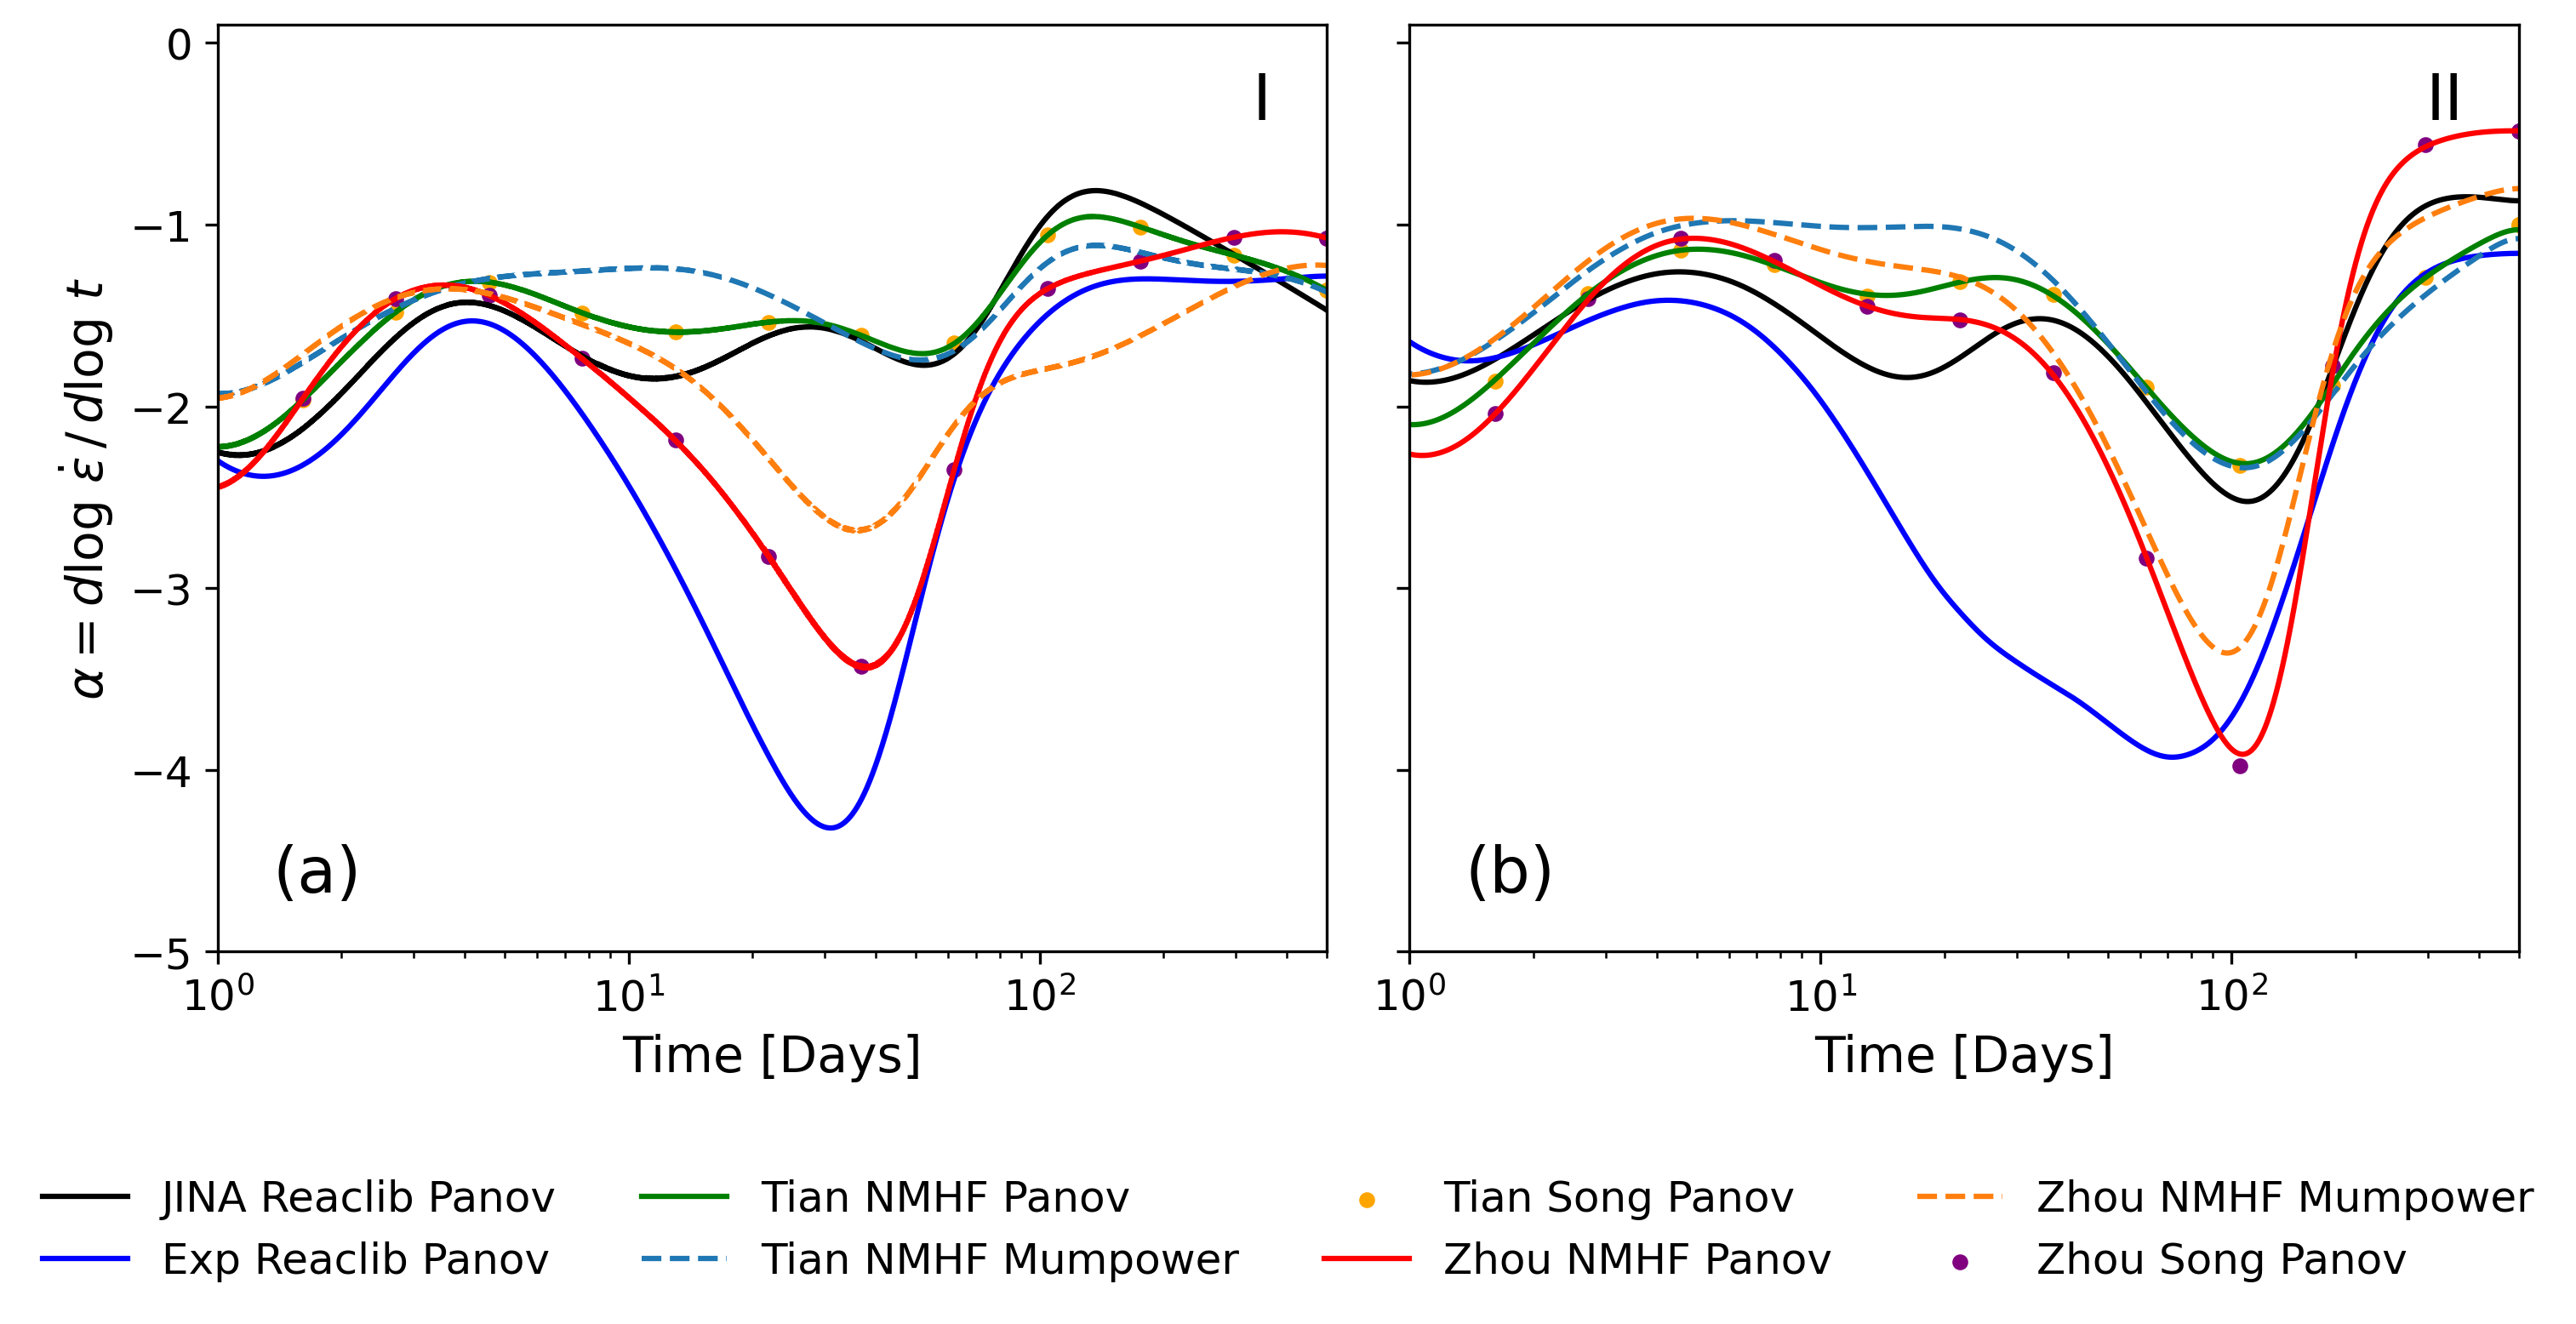

In [7]:

from scipy.ndimage import gaussian_filter1d

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

log_t = np.log10(time_days)

# sub-sample indices (same grid used for Song runs in Figure 4)
song_idx = np.searchsorted(time_days, 10**(np.linspace(-5, np.log10(500), 35))) - 1

def log_slope(E):
    return np.gradient(np.log10(E), log_t)

# sigma in array-index units (10 000 pts over ~2.7 log-decades; sigma=50 ≈ 0.013 dex)
smooth_sigma = 50

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True)

# ---------- subplot (a): Approach I ----------
ax[0].plot(time_days, log_slope(E_I[0]),
           label=r'JINA Reaclib Panov', color='black')
ax[0].plot(time_days, gaussian_filter1d(log_slope(E_I[1]), smooth_sigma),
           label=r'Exp Reaclib Panov', color='blue')
ax[0].plot(time_days, log_slope(E_I[3]),
           label=r'Tian NMHF Panov', color='green')
ax[0].plot(time_days, log_slope(E_I[4]),
           label=r'Tian NMHF Mumpower', linestyle='--')
ax[0].scatter(time_Tian_SONG, log_slope(E_I[5])[song_idx],
              label=r'Tian Song Panov', color='orange', s=12)
ax[0].plot(time_days, log_slope(E_I[7]),
           label=r'Zhou NMHF Panov', color='red')
ax[0].plot(time_days, log_slope(E_I[8]),
           label=r'Zhou NMHF Mumpower', linestyle='--')
ax[0].scatter(time_Zhou_SONG, log_slope(E_I[9])[song_idx],
              label=r'Zhou Song Panov', color='purple', s=12)

ax[0].set_xscale('log')
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'$\alpha = d\log\,\dot\varepsilon\,/\,d\log\,t$')
ax[0].set_xlim(1, 500)

ax[0].text(0.95, 0.95, "I",   transform=ax[0].transAxes, ha="right", va="top",    fontsize=18)
ax[0].text(0.05, 0.05, "(a)", transform=ax[0].transAxes, ha="left",  va="bottom", fontsize=18)

# ---------- subplot (b): Approach II ----------
ax[1].plot(time_days, gaussian_filter1d(log_slope(E_II[0]), smooth_sigma),
           label=r'JINA Reaclib Panov', color='black')
ax[1].plot(time_days, gaussian_filter1d(log_slope(E_II[1]), smooth_sigma),
           label=r'Exp Reaclib Panov', color='blue')
ax[1].plot(time_days, gaussian_filter1d(log_slope(E_II[3]), smooth_sigma),
           label=r'Tian NMHF Panov', color='green')
ax[1].plot(time_days, gaussian_filter1d(log_slope(E_II[4]), smooth_sigma),
           label=r'Tian NMHF Mumpower', linestyle='--')
ax[1].scatter(time_Tian_SONG, log_slope(E_II[6])[song_idx],
              label=r'Tian Song Panov', color='orange', s=12)
ax[1].plot(time_days, gaussian_filter1d(log_slope(E_II[8]), smooth_sigma),
           label=r'Zhou NMHF Panov', color='red')
ax[1].plot(time_days, gaussian_filter1d(log_slope(E_II[9]), smooth_sigma),
           label=r'Zhou NMHF Mumpower', linestyle='--')
ax[1].scatter(time_Zhou_SONG, log_slope(E_II[11])[song_idx],
              label=r'Zhou Song Panov', color='purple', s=12)

ax[1].set_xscale('log')
ax[1].set_xlabel('Time [Days]')
ax[1].set_xlim(1, 500)

ax[1].text(0.95, 0.95, "II",  transform=ax[1].transAxes, ha="right", va="top",    fontsize=18)
ax[1].text(0.05, 0.05, "(b)", transform=ax[1].transAxes, ha="left",  va="bottom", fontsize=18)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.09),
    ncol=4,
    frameon=False
)

plt.ylim(-5,0.1)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("Figure_4b_LogSlope.pdf", bbox_inches="tight")
plt.show()


Figure 5. Results with relevant nuceli

In [ ]:
# Figure Jina Reaclib Approach I

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------- read data ----------
E_I_3_a   = pd.read_csv(approach_I + r'Run_1/Alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b   = pd.read_csv(approach_I + r'Run_1/Beta_minus.csv', sep=',', skiprows=1, header=None)[1].values

E_I_3_a_1 = pd.read_csv(approach_I + r'Run_1/a_top/Es253_1_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_a_2 = pd.read_csv(approach_I + r'Run_1/a_top/Cf252_0_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_a_3 = pd.read_csv(approach_I + r'Run_1/a_top/Ra224_2_alpha.csv', sep=',', skiprows=1, header=None)[1].values

E_I_3_b_2 = pd.read_csv(approach_I + r'Run_1/b_top/I131_0_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b_3 = pd.read_csv(approach_I + r'Run_1/b_top/I133_2_beta.csv', sep=',', skiprows=1, header=None)[1].values

# ---------- create figure with 2 subplots ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=1200, sharex=True)

# ---------- left panel: absolute heating rates ----------
ax[0].plot(time_days, E_I[0], label=r'JINA Reaclib', color='black')

ax[0].plot(time_days, E_I_3_a,   label=r'$\dot\varepsilon_\alpha$', color='red',  linestyle='-')
ax[0].plot(time_days, E_I_3_b,   label=r'$\dot\varepsilon_{\beta^-}$', color='blue', linestyle='-')

ax[0].plot(time_days, E_I_3_a_1, label=r'$^{253}Es$ ($\alpha$)', color='red',  linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_I_3_a_2, label=r'$^{252}Cf$ ($\alpha$)', color='red',  linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_I_3_a_3, label=r'$^{254}Es$ ($\alpha$)', color='red',  linestyle=':',  alpha=0.7)

ax[0].plot(time_days, E_I_3_b_2, label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_I_3_b_3, label=r'$^{133}I$ ($\beta^-$)', color='blue', linestyle=':',  alpha=0.7)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(1, 500)
ax[0].set_ylim(5e4, 5e10)
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].legend(loc='upper right', fontsize=9, frameon=False)

ax[0].text(0.15, 0.95, '(a)', transform=ax[0].transAxes,ha='right', va='top', fontsize=12)

# ---------- right panel: fractions ----------
ax[1].plot(time_days, E_I_3_a / E_I[0], label=r'$\dot\varepsilon_\alpha/\dot\varepsilon$', color='red',  linestyle='-')
ax[1].plot(time_days, E_I_3_b / E_I[0], label=r'$\dot\varepsilon_{\beta^-}/\dot\varepsilon$', color='blue', linestyle='-')

ax[1].plot(time_days, E_I_3_a_1 / E_I[0], label=r'Es253 ($\alpha$)', color='red',  linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_I_3_a_2 / E_I[0], label=r'Cf252 ($\alpha$)', color='red',  linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_I_3_a_3 / E_I[0], label=r'Es254 ($\alpha$)', color='red',  linestyle=':',  alpha=0.7)

ax[1].plot(time_days, E_I_3_b_2 / E_I[0], label=r'I131 ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_I_3_b_3 / E_I[0], label=r'I133 ($\beta^-$)', color='blue', linestyle=':',  alpha=0.7)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 500)
ax[1].set_xlabel('Time [Days]')
ax[1].set_ylabel(r'$\dot\varepsilon_i/\dot\varepsilon$')

ax[1].text(0.15, 0.95, '(b)', transform=ax[1].transAxes,
           ha='right', va='top', fontsize=12)

# ---------- one legend below the full figure ----------
'''
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.05),
           ncol=4,
           frameon=False,
           fontsize=15)
'''
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure_5_I_Jina_Reaclib_per_Nuc.pdf", bbox_inches="tight")
plt.show()

In [ ]:
#Figure Jina Reaclib Approach II

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------- read data ----------
E_II_3_a   = pd.read_csv(approach_II + r'Run_1/Alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b   = pd.read_csv(approach_II + r'Run_1/Beta_minus.csv', sep=',', skiprows=1, header=None)[1].values

E_II_3_a_1 = pd.read_csv(approach_II + r'Run_1/a_top/Es253_0_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_a_2 = pd.read_csv(approach_II + r'Run_1/a_top/Cf252_1_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_a_3 = pd.read_csv(approach_II + r'Run_1/a_top/Es254_3_alpha.csv', sep=',', skiprows=1, header=None)[1].values

E_II_3_b_1 = pd.read_csv(approach_II + r'Run_1/b_top/I132_1_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b_2 = pd.read_csv(approach_II + r'Run_1/b_top/I131_2_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b_3 = pd.read_csv(approach_II + r'Run_1/b_top/I133_3_beta.csv', sep=',', skiprows=1, header=None)[1].values

# ---------- create figure with 2 subplots ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=1200, sharex=True)

# ---------- left panel: absolute heating rates ----------
ax[0].plot(time_days, E_II[0], label=r'JINA Reaclib', color='black')

ax[0].plot(time_days, E_II_3_a,   label=r'$\dot\varepsilon_\alpha$', color='red',  linestyle='-')
ax[0].plot(time_days, E_II_3_b,   label=r'$\dot\varepsilon_{\beta^-}$', color='blue', linestyle='-')

ax[0].plot(time_days, E_II_3_a_1, label=r'$^{253}Es$ ($\alpha$)', color='red',  linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_II_3_a_2, label=r'$^{252}Cf$ ($\alpha$)', color='red',  linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_II_3_a_3, label=r'$^{254}Es$ ($\alpha$)', color='red',  linestyle=':',  alpha=0.7)

ax[0].plot(time_days, E_II_3_b_1, label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_II_3_b_2, label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_II_3_b_3, label=r'$^{133}I$ ($\beta^-$)', color='blue', linestyle=':',  alpha=0.7)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(1, 500)
ax[0].set_ylim(5e4, 5e10)
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].legend(loc='upper right', fontsize=9, frameon=False)

# panel label
ax[0].text(0.15, 0.95, '(a)', transform=ax[0].transAxes,
           ha='right', va='top', fontsize=12)

# ---------- right panel: fractions ----------
ax[1].plot(time_days, E_II_3_a   / E_II[0], label=r'$\dot\varepsilon_\alpha/\dot\varepsilon$', color='red',  linestyle='-')
ax[1].plot(time_days, E_II_3_b   / E_II[0], label=r'$\dot\varepsilon_{\beta^-}/\dot\varepsilon$', color='blue', linestyle='-')

ax[1].plot(time_days, E_II_3_a_1 / E_II[0], label=r'$^{253}Es$ ($\alpha$)', color='red',  linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_II_3_a_2 / E_II[0], label=r'$^{252}Cf$ ($\alpha$)', color='red',  linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_II_3_a_3 / E_II[0], label=r'$^{254}Es$ ($\alpha$)', color='red',  linestyle=':',  alpha=0.7)

ax[1].plot(time_days, E_II_3_b_1 / E_II[0], label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_2 / E_II[0], label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_3 / E_II[0], label=r'$^{133}I$ ($\beta^-$)', color='blue', linestyle=':',  alpha=0.7)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 500)
ax[1].set_ylim(0, 1.1)
ax[1].set_xlabel('Time [Days]')
ax[1].set_ylabel(r'$\dot\varepsilon_i/\dot\varepsilon$')

# panel label
ax[1].text(0.15, 0.95, '(b)', transform=ax[1].transAxes,
           ha='right', va='top', fontsize=12)

# ---------- one legend below the full figure ----------
#handles, labels = ax[0].get_legend_handles_labels()
#fig.legend(handles, labels,
#           loc='upper center',
#           bbox_to_anchor=(0.5, 0.05),
#           ncol=4,
#           frameon=False,
#           fontsize=15)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure_5_II_Jina_Reaclib_per_nuc.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Figure Tian NMHF Panov approach I

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------- read data ----------
E_I_3_a   = pd.read_csv(approach_I + r'Run_3/Alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b   = pd.read_csv(approach_I + r'Run_3/Beta_minus.csv', sep=',', skiprows=1, header=None)[1].values

E_I_3_a_1 = pd.read_csv(approach_I + r'Run_3/a_top/Cf252_0_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_a_2 = pd.read_csv(approach_I + r'Run_3/a_top/Es253_2_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_a_3 = pd.read_csv(approach_I + r'Run_3/a_top/Es254_4_alpha.csv', sep=',', skiprows=1, header=None)[1].values

E_I_3_b_1 = pd.read_csv(approach_I + r'Run_3/b_top/I131_0_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b_2 = pd.read_csv(approach_I + r'Run_3/b_top/I133_3_beta.csv', sep=',', skiprows=1, header=None)[1].values

# ---------- create figure with 2 subplots ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=1200, sharex=True)

# =========================================================
# left panel: absolute heating rates
# =========================================================
ax[0].plot(time_days, E_I[3], label=r'Tian NMHF Panov', color='black')

ax[0].plot(time_days, E_I_3_a, label=r'$\dot\varepsilon_\alpha$', color='red', linestyle='-')
ax[0].plot(time_days, E_I_3_b, label=r'$\dot\varepsilon_{\beta^-}$', color='blue', linestyle='-')

ax[0].plot(time_days, E_I_3_a_1, label=r'$^{252}Cf$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_I_3_a_2, label=r'$^{253}Es$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_I_3_a_3, label=r'$^{254}Es$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)

ax[0].plot(time_days, E_I_3_b_1, label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_I_3_b_2, label=r'$^{133}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(1, 500)
ax[0].set_ylim(5e4, 5e10)
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].legend(loc='upper right', fontsize=9, frameon=False)
ax[0].text(
    0.15, 0.95, '(c)',
    transform=ax[0].transAxes,
    ha='right', va='top',
    fontsize=12
)

# =========================================================
# right panel: fractional contributions
# =========================================================
ax[1].plot(time_days, E_I_3_a / E_I[3], label=r'$\dot\varepsilon_\alpha / \dot\varepsilon$', color='red', linestyle='-')
ax[1].plot(time_days, E_I_3_b / E_I[3], label=r'$\dot\varepsilon_{\beta^-} / \dot\varepsilon$', color='blue', linestyle='-')

ax[1].plot(time_days, E_I_3_a_1 / E_I[3], label=r'$^{252}Cf$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_I_3_a_2 / E_I[3], label=r'$^{253}Es$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_I_3_a_3 / E_I[3], label=r'$^{254}Es$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)

ax[1].plot(time_days, E_I_3_b_1 / E_I[3], label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_I_3_b_2 / E_I[3], label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 500)
ax[1].set_ylim(0, 1.1)
ax[1].set_xlabel('Time [Days]')
ax[1].set_ylabel(r'$\dot\varepsilon_i / \dot\varepsilon$')

ax[1].text(
    0.15, 0.95, '(d)',
    transform=ax[1].transAxes,
    ha='right', va='top',
    fontsize=12
)

# ---------- one legend below the figure ----------
#handles, labels = ax[0].get_legend_handles_labels()
#fig.legend(
#    handles, labels,
#    loc='upper center',
#    bbox_to_anchor=(0.5, 0.05),
#    ncol=4,
#    frameon=False,
#    fontsize=15
#)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure_5_I_Tian_NMHF_Panov_per_nuc.pdf", bbox_inches="tight")
plt.show()

In [ ]:
#Figure Tian NMHF Panov approach II

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------- read data once ----------
E_II_3_a   = pd.read_csv(approach_II + r'Run_Tian_NMHF/Alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b   = pd.read_csv(approach_II + r'Run_Tian_NMHF/Beta_minus.csv', sep=',', skiprows=1, header=None)[1].values

E_II_3_a_1 = pd.read_csv(approach_II + r'Run_Tian_NMHF/a_top/Cf252_0_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_a_2 = pd.read_csv(approach_II + r'Run_Tian_NMHF/a_top/Es253_2_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_a_3 = pd.read_csv(approach_II + r'Run_Tian_NMHF/a_top/Fm254_3_alpha.csv', sep=',', skiprows=1, header=None)[1].values

E_II_3_b_1 = pd.read_csv(approach_II + r'Run_Tian_NMHF/b_top/I131_2_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b_2 = pd.read_csv(approach_II + r'Run_Tian_NMHF/b_top/I132_1_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b_3 = pd.read_csv(approach_II + r'Run_Tian_NMHF/b_top/Sb128_3_beta.csv', sep=',', skiprows=1, header=None)[1].values


# ---------- create figure with 2 subplots ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=1200, sharex=True)

# =========================================================
# left panel: absolute heating rates
# =========================================================
ax[0].plot(time_days, E_II[3], label=r'Tian NMHF Panov', color='black')

ax[0].plot(time_days, E_II_3_a, color='red', linestyle='-')
ax[0].plot(time_days, E_II_3_b, color='blue', linestyle='-')

ax[0].plot(time_days, E_II_3_a_1, label=r'$^{252}Cf$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_II_3_a_2, label=r'$^{253}Es$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_II_3_a_3, label=r'$^{254}Fm$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)

ax[0].plot(time_days, E_II_3_b_1, label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_II_3_b_2, label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_II_3_b_3, label=r'$^{128}Sb$ ($\beta^-$)', color='blue', linestyle=':', alpha=0.7)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(1, 500)
ax[0].set_ylim(5e4, 5e10)
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].legend(loc='upper right', fontsize=9, frameon=False)
ax[0].text(
    0.15, 0.95, '(c)',
    transform=ax[0].transAxes,
    ha='right', va='top',
    fontsize=12
)

# =========================================================
# right panel: fractional contributions
# =========================================================
ax[1].plot(time_days, E_II_3_a / E_II[3], label=r'$\dot\varepsilon_\alpha / \dot\varepsilon$', color='red', linestyle='-')
ax[1].plot(time_days, E_II_3_b / E_II[3], label=r'$\dot\varepsilon_{\beta^-} / \dot\varepsilon$', color='blue', linestyle='-')
ax[1].plot(time_days, E_II_3_a_1 / E_II[3], label=r'$^{252}Cf$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_II_3_a_2 / E_II[3], label=r'$^{253}Es$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_II_3_a_3 / E_II[3], label=r'$^{254}Fm$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_1 / E_II[3], label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_2 / E_II[3], label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_3 / E_II[3], label=r'$^{128}Sb$ ($\beta^-$)', color='blue', linestyle=':', alpha=0.7)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 500)
ax[1].set_ylim(0, 1.1)
ax[1].set_xlabel('Time [Days]')
ax[1].set_ylabel(r'$\dot\varepsilon_i / \dot\varepsilon$')

ax[1].text(
    0.15, 0.95, '(d)',
    transform=ax[1].transAxes,
    ha='right', va='top',
    fontsize=12
)

# ---------- one legend below the figure ----------
#handles, labels = ax[0].get_legend_handles_labels()
#fig.legend(
#    handles, labels,
#    loc='upper center',
#    bbox_to_anchor=(0.5, 0.05),
#    ncol=4,
#    frameon=False,
#    fontsize=15
#)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure_5_II_Tian_NMHF_Panov_per_nuc.pdf", bbox_inches="tight")
plt.show()

In [ ]:
#Zhou NMHF Panov approach I
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------- read absolute-rate panel data ----------
E_I_3_a   = pd.read_csv(approach_I + r'Run_10/Alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b   = pd.read_csv(approach_I + r'Run_10/Beta_minus.csv', sep=',', skiprows=1, header=None)[1].values

E_I_3_a_1 = pd.read_csv(approach_I + r'Run_10/a_top/Th228_0_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_a_2 = pd.read_csv(approach_I + r'Run_10/a_top/Ac225_1_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_a_4 = pd.read_csv(approach_I + r'Run_10/a_top/Ra223_2_alpha.csv', sep=',', skiprows=1, header=None)[1].values

E_I_3_b_1 = pd.read_csv(approach_I + r'Run_10/b_top/I131_2_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b_2 = pd.read_csv(approach_I + r'Run_10/b_top/Sn123_1_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_I_3_b_3 = pd.read_csv(approach_I + r'Run_10/b_top/Sb125_0_beta.csv', sep=',', skiprows=1, header=None)[1].values

# ---------- create figure ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=1200, sharex=True)

# =========================================================
# left panel: absolute heating rates
# =========================================================
ax[0].plot(time_days, E_I[7], label=r'Zhou NMHF Panov', color='black')

ax[0].plot(time_days, E_I_3_a, color='red', linestyle='-')
ax[0].plot(time_days, E_I_3_b, color='blue', linestyle='-')

ax[0].plot(time_days, E_I_3_a_1, label=r'$^{228}Th$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_I_3_a_2, label=r'$^{225}Ac$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_I_3_a_4, label=r'$^{223}Ra$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)

ax[0].plot(time_days, E_I_3_b_1, label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_I_3_b_2, label=r'$^{123}Sn$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_I_3_b_3, label=r'$^{125}Sb$ ($\beta^-$)', color='blue', linestyle=':', alpha=0.7)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(1, 500)
ax[0].set_ylim(2e3, 5e10)
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].legend(loc='upper right', fontsize=9, frameon=False)

ax[0].text(
    0.15, 0.95, '(e)',
    transform=ax[0].transAxes,
    ha='right', va='top',
    fontsize=12
)

# =========================================================
# right panel: fractional contributions
# =========================================================
ax[1].plot(time_days, E_I_3_a / E_I[7], label=r'$\dot\varepsilon_\alpha / \dot\varepsilon$', color='red', linestyle='-')
ax[1].plot(time_days, E_I_3_b / E_I[7], label=r'$\dot\varepsilon_{\beta^-} / \dot\varepsilon$', color='blue', linestyle='-')

ax[1].plot(time_days, E_I_3_a_1 / E_I[7], label=r'$^{228}Th$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_I_3_a_2 / E_I[7], label=r'$^{225}Ac$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_I_3_a_4 / E_I[7], label=r'$^{223}Ra$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)

ax[1].plot(time_days, E_I_3_b_1 / E_I[7], label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_I_3_b_2 / E_I[7], label=r'$^{123}Sn$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_I_3_b_3 / E_I[7], label=r'$^{125}Sb$ ($\beta^-$)', color='blue', linestyle=':', alpha=0.7)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 500)
ax[1].set_ylim(0, 1.1)
ax[1].set_xlabel('Time [Days]')
ax[1].set_ylabel(r'$\dot\varepsilon_i/\dot\varepsilon$')

ax[1].text(
    0.15, 0.95, '(f)',
    transform=ax[1].transAxes,
    ha='right', va='top',
    fontsize=12
)

# ---------- legend from both panels ----------
handles, labels = ax[0].get_legend_handles_labels()

#
#fig.legend(
#    handles, labels,
#    loc='upper center',
#    bbox_to_anchor=(0.5, 0.05),
#    ncol=4,
#    frameon=False,
#    fontsize=15
#)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure_5_I_Zhou_NMHF_per_nuc.pdf", bbox_inches="tight")
plt.show()

In [ ]:
#Figure Zhou NMHF Panov approach II

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------- read absolute-rate panel data ----------
E_II_3_a   = pd.read_csv(approach_II + r'Run_Zhou_NMHF/Alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b   = pd.read_csv(approach_II + r'Run_Zhou_NMHF/Beta_minus.csv', sep=',', skiprows=1, header=None)[1].values

E_II_3_a_1 = pd.read_csv(approach_II + r'Run_Zhou_NMHF/a_top/Po213_1_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_a_2 = pd.read_csv(approach_II + r'Run_Zhou_NMHF/a_top/At217_2_alpha.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_a_4 = pd.read_csv(approach_II + r'Run_Zhou_NMHF/a_top/Po215_6_alpha.csv', sep=',', skiprows=1, header=None)[1].values

E_II_3_b_1 = pd.read_csv(approach_II + r'Run_Zhou_NMHF/b_top/I132_2_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b_2 = pd.read_csv(approach_II + r'Run_Zhou_NMHF/b_top/Sn123_4_beta.csv', sep=',', skiprows=1, header=None)[1].values
E_II_3_b_3 = pd.read_csv(approach_II + r'Run_Zhou_NMHF/b_top/I131_3_beta.csv', sep=',', skiprows=1, header=None)[1].values

# ---------- create figure ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=1200, sharex=True)

# =========================================================
# left panel: absolute heating rates
# =========================================================
ax[0].plot(time_days, E_II[8], label=r'Zhou NMHF Panov', color='black')

ax[0].plot(time_days, E_II_3_a,  color='red', linestyle='-')
ax[0].plot(time_days, E_II_3_b, color='blue', linestyle='-')

ax[0].plot(time_days, E_II_3_a_1, label=r'$^{213}Po$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_II_3_a_2, label=r'$^{217}At$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_II_3_a_4, label=r'$^{215}Po$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)

ax[0].plot(time_days, E_II_3_b_1, label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[0].plot(time_days, E_II_3_b_2, label=r'$^{123}Sn$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[0].plot(time_days, E_II_3_b_3, label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle=':', alpha=0.7)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(1, 500)
ax[0].set_ylim(1e4, 1e11)
ax[0].set_xlabel('Time [Days]')
ax[0].set_ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
ax[0].legend(loc='upper right', fontsize=9, frameon=False)
ax[0].text(
    0.15, 0.95, '(e)',
    transform=ax[0].transAxes,
    ha='right', va='top',
    fontsize=12
)

# =========================================================
# right panel: fractional contributions
# =========================================================
ax[1].plot(time_days, E_II_3_a / E_II[8], label=r'$\dot\varepsilon_\alpha / \dot\varepsilon$', color='red', linestyle='-')
ax[1].plot(time_days, E_II_3_b / E_II[8], label=r'$\dot\varepsilon_{\beta^-} / \dot\varepsilon$', color='blue', linestyle='-')
ax[1].plot(time_days, E_II_3_a_1 / E_II[8], label=r'$^{213}Po$ ($\alpha$)', color='red', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_II_3_a_2 / E_II[8], label=r'$^{217}At$ ($\alpha$)', color='red', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_II_3_a_4 / E_II[8], label=r'$^{215}Po$ ($\alpha$)', color='red', linestyle=':', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_1 / E_II[8], label=r'$^{132}I$ ($\beta^-$)', color='blue', linestyle='-.', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_2 / E_II[8], label=r'$^{123}Sn$ ($\beta^-$)', color='blue', linestyle='--', alpha=0.7)
ax[1].plot(time_days, E_II_3_b_3 / E_II[8], label=r'$^{131}I$ ($\beta^-$)', color='blue', linestyle=':', alpha=0.7)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 500)
ax[1].set_ylim(0, 1)
ax[1].set_xlabel('Time [Days]')
ax[1].set_ylabel(r'$\dot\varepsilon_i/\dot\varepsilon$')

ax[1].text(
    0.15, 0.95, '(f)',
    transform=ax[1].transAxes,
    ha='right', va='top',
    fontsize=12
)

# ---------- combined legend from both panels ----------
handles, labels = ax[0].get_legend_handles_labels()

#
#fig.legend(
#    handles, labels,
#    loc='upper center',
#    bbox_to_anchor=(0.5, 0.05),
#    ncol=4,
#    frameon=False,
#    fontsize=15
#)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure_5_II_Zhou_NMHF_per_nuc.pdf", bbox_inches="tight")
plt.show()